# Phase 5: Explainable AI for Quantitative DDI LD50 Prediction

This notebook applies multiple explainability methods to understand why the selected Phase 4 model predicts a particular mixture toxicity value for a pair of drugs. The goal is to produce chemically meaningful explanations by identifying the atoms and fragments that contribute most strongly to the predicted LD50 toxicity.

## Main steps

1. **Load the best Phase 4 regression model**  
   The selected dual-encoder regression model and its transferred encoder are reloaded so that explanations are generated from the final toxicity predictor.

2. **Load the unified mixture toxicity dataset and metadata**  
   The graph pairs, toxicity targets, scaler, and processed metadata are loaded to allow both prediction and mapping back to drug names and molecular structures.

3. **Recreate the Phase 4 test split**  
   The same held-out test split is reconstructed so that explainability benchmarking is performed on unseen samples.

4. **Implement multiple suitable XAI methods**  
   Several atom-level explainers are compared, including Saliency, Gradient x Input, Integrated Gradients, SmoothGrad, and Feature Ablation.

5. **Benchmark all XAI methods**  
   Each method is evaluated using explanation-quality criteria such as faithfulness, stability, and sanity.

6. **Select the best XAI method**  
   The final explainer is chosen based on its overall benchmark performance rather than by assuming a single method in advance.

7. **Explain a target drug pair**  
   The selected XAI method is used to explain a specific pair, such as Morpholine + Toluene, by identifying the most influential atoms and fragments in both drugs.

8. **Visualize and summarize explanations**  
   Molecule drawings, atom-importance bar charts, fragment extraction, and textual summaries are used to present the explanation clearly.

The notebook produces:
- a benchmark comparison of XAI methods
- the selected best explainer
- atom-level and fragment-level explanations for the target pair
- saved explanation summaries for reporting and discussion

In [1]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric
!pip install captum
!pip install pubchempy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# In[2] - updated imports

import os
import copy
import random
import joblib
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

import pubchempy as pcp

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Change this to your own local folder
base_path = r'C:\Users\msi\Downloads\IRP Jupiter nb\Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

best_reg_model_path = os.path.join(processed_dir, 'best_ddi_reg_model.pt')
best_reg_encoder_path = os.path.join(processed_dir, 'best_ddi_reg_encoder.pt')
mixture_raw_path = os.path.join(processed_dir, 'unified_mixture_toxicity.pt')
mixture_scaled_path = os.path.join(processed_dir, 'unified_mixture_toxicity_scaled.pt')
mixture_scaler_path = os.path.join(processed_dir, 'mixture_toxicity_scaler.pkl')
mixture_csv_path = os.path.join(base_path, 'unified_mixture_toxicity_processed.csv')

print("best_reg_model_path:", best_reg_model_path)
print("mixture_raw_path:", mixture_raw_path)
print("mixture_scaled_path:", mixture_scaled_path)
print("mixture_scaler_path:", mixture_scaler_path)
print("mixture_csv_path:", mixture_csv_path)

Using device: cuda
best_reg_model_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_reg_model.pt
mixture_raw_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity.pt
mixture_scaled_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity_scaled.pt
mixture_scaler_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\mixture_toxicity_scaler.pkl
mixture_csv_path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\unified_mixture_toxicity_processed.csv


## Reproducibility

Keeps the explainability benchmark stable and reproducible.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Phase 4 encoder classes

The encoder must exactly match the architecture used in the current Phase 4 workflow.

In [5]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder

## Phase 4 regression heads

The explainability stage must rebuild the exact regression head selected in Phase 4.

In [6]:
class DualEncoderConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        fused = torch.cat([emb_a, emb_b], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        fused = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderBilinearConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.bilinear = nn.Bilinear(emb_dim, emb_dim, emb_dim)
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        bilinear_term = self.bilinear(emb_a, emb_b)
        fused = torch.cat([emb_a, emb_b, prod, bilinear_term], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderAbsDiffConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        abs_diff = torch.abs(emb_a - emb_b)
        fused = torch.cat([emb_a, emb_b, abs_diff], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderSymmetricFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        emb_sum = emb_a + emb_b
        abs_diff = torch.abs(emb_a - emb_b)
        prod = emb_a * emb_b
        fused = torch.cat([emb_sum, abs_diff, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderGatedFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        gate = self.gate(torch.cat([emb_a, emb_b], dim=1))
        fused_main = gate * emb_a + (1.0 - gate) * emb_b
        prod = emb_a * emb_b
        fused = torch.cat([fused_main, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


def build_regression_model(model_name, encoder_meta, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatRegressor":
        return DualEncoderConcatRegressor(encoder, dropout=dropout)
    elif model_name == "ConcatProdRegressor":
        return DualEncoderConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "BilinearConcatProdRegressor":
        return DualEncoderBilinearConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "AbsDiffConcatRegressor":
        return DualEncoderAbsDiffConcatRegressor(encoder, dropout=dropout)
    elif model_name == "SymmetricFusionRegressor":
        return DualEncoderSymmetricFusionRegressor(encoder, dropout=dropout)
    elif model_name == "GatedFusionRegressor":
        return DualEncoderGatedFusionRegressor(encoder, dropout=dropout)
    else:
        raise ValueError(f"Unknown regression model: {model_name}")

## Load Phase 4 model metadata and rebuild the trained model

This guarantees that explanations are produced for the exact model selected in Phase 4.

In [7]:
phase4_meta = torch.load(
    best_reg_model_path,
    map_location='cpu',
    weights_only=False
)

print("Loaded Phase 4 model info:")
print("Selected model:", phase4_meta["model_name"])
print("Best validation MAE:", phase4_meta["best_val_mae"])
print("Best epoch:", phase4_meta["best_epoch"])

model = build_regression_model(
    model_name=phase4_meta["model_name"],
    encoder_meta=phase4_meta["encoder_meta"],
    dropout=phase4_meta["dropout"]
).to(device)

model.load_state_dict(phase4_meta["model_state_dict"])
model.eval()

print("Phase 4 regression model loaded successfully.")

Loaded Phase 4 model info:
Selected model: SymmetricFusionRegressor
Best validation MAE: 0.308227
Best epoch: 49
Phase 4 regression model loaded successfully.


## Load graph datasets and scaler safely

We need graph pairs for explanation, raw targets for interpretation, and a scaler for inverse transformation.

In [8]:
raw_data = torch.load(mixture_raw_path, map_location='cpu', weights_only=False)
scaled_data = torch.load(mixture_scaled_path, map_location='cpu', weights_only=False)

graphs_a_raw, graphs_b_raw, targets_raw = raw_data
graphs_a_scaled, graphs_b_scaled, targets_scaled = scaled_data

if torch.is_tensor(targets_raw):
    targets_raw = targets_raw.view(-1).float()
else:
    targets_raw = torch.tensor(targets_raw, dtype=torch.float)

if torch.is_tensor(targets_scaled):
    targets_scaled = targets_scaled.view(-1).float()
else:
    targets_scaled = torch.tensor(targets_scaled, dtype=torch.float)

try:
    mixture_scaler = joblib.load(mixture_scaler_path)
    print("Scaler loaded successfully.")
except Exception:
    print("Scaler load failed. Rebuilding scaler from raw targets...")
    mixture_scaler = StandardScaler()
    mixture_scaler.fit(targets_raw.cpu().numpy().reshape(-1, 1))

print("Number of graph pairs:", len(graphs_a_raw))
print("Raw target range:", float(targets_raw.min()), "to", float(targets_raw.max()))
print("Scaled target mean:", float(targets_scaled.mean()))
print("Scaled target std:", float(targets_scaled.std()))

Scaler load failed. Rebuilding scaler from raw targets...
Number of graph pairs: 387
Raw target range: 0.14688006043434143 to 4.539128303527832
Scaled target mean: 1.7711974109602124e-09
Scaled target std: 1.001294493675232


## Load processed metadata CSV

This lets you map graph indices back to drug names, sources, and SMILES strings.

In [9]:
df_meta = pd.read_csv(mixture_csv_path)
print("Metadata shape:", df_meta.shape)
display(df_meta.head())

# Ensure required columns exist
required_cols = ["SMILES_A", "SMILES_B", "Target_neglog_molkg"]
for col in required_cols:
    if col not in df_meta.columns:
        raise ValueError(f"Missing required column: {col}")

# Create fallback name columns if they do not exist
if "DrugA" not in df_meta.columns:
    df_meta["DrugA"] = [f"Drug_A_{i}" for i in range(len(df_meta))]

if "DrugB" not in df_meta.columns:
    df_meta["DrugB"] = [f"Drug_B_{i}" for i in range(len(df_meta))]

if "source" not in df_meta.columns:
    df_meta["source"] = "Unknown"

print("Columns available:")
print(df_meta.columns.tolist())

Metadata shape: (387, 5)


,PairKey,SMILES_A,SMILES_B,Target_neglog_molkg,source
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1||CCCCC...,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312,Acute_Oral_Toxicity
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102,Acute_Oral_Toxicity
3,C1COCCN1||C1COCCO1,C1COCCN1,C1COCCO1,1.359363,Smyth
4,C1COCCN1||C=CC#N,C1COCCN1,C=CC#N,2.130152,Smyth


Columns available:
['PairKey', 'SMILES_A', 'SMILES_B', 'Target_neglog_molkg', 'source', 'DrugA', 'DrugB']


## Recreate the same test split as Phase 4

The explainability benchmark should be run on the same held-out test portion used in Phase 4.

In [10]:
def make_regression_bins(y, n_bins=5):
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.array(y)
    bins = pd.qcut(y_np, q=n_bins, labels=False, duplicates='drop')
    return np.asarray(bins)

bins = make_regression_bins(targets_scaled, n_bins=5)
all_indices = np.arange(len(targets_scaled))

splitter_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(splitter_1.split(all_indices, bins))

splitter_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_sub_idx, val_sub_idx = next(splitter_2.split(train_val_idx, bins[train_val_idx]))

train_idx = train_val_idx[train_sub_idx]
val_idx = train_val_idx[val_sub_idx]

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 270
Validation size: 58
Test size: 59


## Basic prediction helpers

These helper functions simplify prediction and inverse transformation.

In [11]:
def prepare_single_graph(g, device):
    g = g.clone().to(device)
    g.batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    return g

def predict_scaled(model, graph_a, graph_b):
    model.eval()
    with torch.no_grad():
        out, _ = model(graph_a, graph_b)
    return float(out.view(-1)[0].item())

def predict_original(model, graph_a, graph_b, scaler):
    pred_scaled = predict_scaled(model, graph_a, graph_b)
    pred_original = scaler.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
    return float(pred_original)

def classify_toxicity_level(pred_pld50):
    if pred_pld50 >= 3.5:
        return "extremely highly toxic"
    elif pred_pld50 >= 3.0:
        return "very highly toxic"
    elif pred_pld50 >= 2.5:
        return "highly toxic"
    elif pred_pld50 >= 2.0:
        return "moderately toxic"
    elif pred_pld50 >= 1.5:
        return "mildly toxic"
    else:
        return "very mildly toxic"

## Utility functions for explainers

These helpers make all explainers compatible with your dual-encoder graph regression model.

In [12]:
def clone_graph_with_x(graph, new_x):
    g = graph.clone()
    g.x = new_x
    if not hasattr(g, "batch") or g.batch is None:
        g.batch = torch.zeros(g.x.size(0), dtype=torch.long, device=g.x.device)
    return g

def forward_from_x(model, graph_a, graph_b, x_a, x_b):
    g_a = clone_graph_with_x(graph_a, x_a)
    g_b = clone_graph_with_x(graph_b, x_b)
    pred, _ = model(g_a, g_b)
    return pred.view(-1).sum()

def normalize_importance(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

def safe_pearson(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(pearsonr(a, b)[0])

## XAI methods evaluated

The explainability stage uses post-hoc methods that are compatible with the trained
dual-encoder graph regression model and with the current interpretation pipeline, which
converts feature-level importance into atom-level importance and then into fragment-level
and textual explanations.

Included methods:

- Saliency:
  A first-order gradient method. It is fast and provides a simple baseline.

- Gradient x Input:
  Extends raw gradients by weighting them with the original input values.

- Integrated Gradients:
  A path-based attribution method that is usually more stable than raw gradients.

- SmoothGrad:
  Averages gradients over noisy copies of the input to reduce explanation noise.

- Feature Ablation:
  A perturbation-based method that removes one atom representation at a time and measures
  the change in prediction. This is highly compatible with chemical interpretation.

- GNNExplainerStyleMask:
  A node-mask optimization approach inspired by GNNExplainer. It learns sparse masks over
  graph nodes so that only the most important atoms are kept while preserving the prediction.

Methods not included in the final benchmark:

- DeepLift and GradientSHAP were tested conceptually but excluded from the final benchmark.
  These methods are designed for tensor inputs with a clear batch dimension, whereas the current
  PyTorch Geometric model operates on variable-size graph node matrices where the first dimension
  represents atoms, not independent batch samples. Captum baseline expansion changes this
  dimension in a way that breaks graph batching and global pooling. Therefore, these methods are
  not safely compatible with the current dual-graph regression pipeline without major redesign.

- Intrinsic models such as Linear Regression and Decision Trees were not included because
  they would replace the trained GNN rather than explain it.

- GradCAM was not included because it is mainly designed for convolutional image feature maps
  and does not naturally align with the current graph encoder architecture.

- Exact SHAP, LIME, descriptor-surrogate methods, counterfactual generators, and similarity maps
  were not included in this benchmark because they are either computationally impractical for
  graph-pair inputs or require a different interpretation pipeline from the current atom-level
  and fragment-level explanation workflow.

In [13]:
def explain_saliency(model, graph_a, graph_b, device):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device).requires_grad_(True)
    x_b = graph_b.x.clone().detach().to(device).requires_grad_(True)

    pred = forward_from_x(model, graph_a, graph_b, x_a, x_b)
    model.zero_grad()
    pred.backward()

    imp_a = x_a.grad.detach().abs().sum(dim=1).cpu().numpy()
    imp_b = x_b.grad.detach().abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_grad_input(model, graph_a, graph_b, device):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device).requires_grad_(True)
    x_b = graph_b.x.clone().detach().to(device).requires_grad_(True)

    pred = forward_from_x(model, graph_a, graph_b, x_a, x_b)
    model.zero_grad()
    pred.backward()

    imp_a = (x_a.grad.detach() * x_a.detach()).abs().sum(dim=1).cpu().numpy()
    imp_b = (x_b.grad.detach() * x_b.detach()).abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_integrated_gradients(model, graph_a, graph_b, device, steps=40):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device)
    x_b = graph_b.x.clone().detach().to(device)

    baseline_a = torch.zeros_like(x_a)
    baseline_b = torch.zeros_like(x_b)

    total_grad_a = torch.zeros_like(x_a)
    total_grad_b = torch.zeros_like(x_b)

    for alpha in np.linspace(0.0, 1.0, steps):
        x_interp_a = (baseline_a + alpha * (x_a - baseline_a)).detach().requires_grad_(True)
        x_interp_b = (baseline_b + alpha * (x_b - baseline_b)).detach().requires_grad_(True)

        pred = forward_from_x(model, graph_a, graph_b, x_interp_a, x_interp_b)
        model.zero_grad()
        pred.backward()

        total_grad_a += x_interp_a.grad.detach()
        total_grad_b += x_interp_b.grad.detach()

    avg_grad_a = total_grad_a / steps
    avg_grad_b = total_grad_b / steps

    attr_a = (x_a - baseline_a) * avg_grad_a
    attr_b = (x_b - baseline_b) * avg_grad_b

    imp_a = attr_a.abs().sum(dim=1).cpu().numpy()
    imp_b = attr_b.abs().sum(dim=1).cpu().numpy()
    return imp_a, imp_b


def explain_smoothgrad(model, graph_a, graph_b, device, n_samples=20, noise_std=0.02):
    model.eval()

    x_a = graph_a.x.clone().detach().to(device)
    x_b = graph_b.x.clone().detach().to(device)

    total_imp_a = np.zeros(x_a.size(0), dtype=float)
    total_imp_b = np.zeros(x_b.size(0), dtype=float)

    for _ in range(n_samples):
        noisy_a = (x_a + torch.randn_like(x_a) * noise_std).detach().requires_grad_(True)
        noisy_b = (x_b + torch.randn_like(x_b) * noise_std).detach().requires_grad_(True)

        pred = forward_from_x(model, graph_a, graph_b, noisy_a, noisy_b)
        model.zero_grad()
        pred.backward()

        total_imp_a += noisy_a.grad.detach().abs().sum(dim=1).cpu().numpy()
        total_imp_b += noisy_b.grad.detach().abs().sum(dim=1).cpu().numpy()

    imp_a = total_imp_a / n_samples
    imp_b = total_imp_b / n_samples
    return imp_a, imp_b


def explain_feature_ablation(model, graph_a, graph_b, device):
    model.eval()

    pred_orig = predict_scaled(model, graph_a, graph_b)
    imp_a = np.zeros(graph_a.x.size(0), dtype=float)
    imp_b = np.zeros(graph_b.x.size(0), dtype=float)

    for i in range(graph_a.x.size(0)):
        g_a_masked = graph_a.clone()
        g_a_masked.x[i] = torch.zeros_like(g_a_masked.x[i])
        pred_masked = predict_scaled(model, g_a_masked, graph_b)
        imp_a[i] = abs(pred_orig - pred_masked)

    for i in range(graph_b.x.size(0)):
        g_b_masked = graph_b.clone()
        g_b_masked.x[i] = torch.zeros_like(g_b_masked.x[i])
        pred_masked = predict_scaled(model, graph_a, g_b_masked)
        imp_b[i] = abs(pred_orig - pred_masked)

    return imp_a, imp_b


def explain_gnnexplainer_style_mask(
    model,
    graph_a,
    graph_b,
    device,
    epochs=80,
    lr=0.05,
    size_coeff=0.02,
    ent_coeff=0.005
):
    """
    GNNExplainer-style node-mask optimization for dual-graph regression.
    Learns sparse node masks for both molecules while preserving the prediction.
    """
    model.eval()

    x_a = graph_a.x.clone().detach().to(device)
    x_b = graph_b.x.clone().detach().to(device)

    with torch.no_grad():
        target_pred = forward_from_x(model, graph_a, graph_b, x_a, x_b).detach()

    mask_logits_a = torch.nn.Parameter(torch.zeros(x_a.size(0), device=device))
    mask_logits_b = torch.nn.Parameter(torch.zeros(x_b.size(0), device=device))

    optimizer = torch.optim.Adam([mask_logits_a, mask_logits_b], lr=lr)

    for _ in range(epochs):
        optimizer.zero_grad()

        mask_a = torch.sigmoid(mask_logits_a).unsqueeze(1)
        mask_b = torch.sigmoid(mask_logits_b).unsqueeze(1)

        pred_masked = forward_from_x(model, graph_a, graph_b, x_a * mask_a, x_b * mask_b)

        pred_loss = (pred_masked - target_pred).pow(2)

        size_loss = mask_a.mean() + mask_b.mean()

        entropy_a = -mask_a * torch.log(mask_a + 1e-8) - (1 - mask_a) * torch.log(1 - mask_a + 1e-8)
        entropy_b = -mask_b * torch.log(mask_b + 1e-8) - (1 - mask_b) * torch.log(1 - mask_b + 1e-8)
        ent_loss = entropy_a.mean() + entropy_b.mean()

        loss = pred_loss + size_coeff * size_loss + ent_coeff * ent_loss
        loss.backward()
        optimizer.step()

    imp_a = torch.sigmoid(mask_logits_a).detach().cpu().numpy()
    imp_b = torch.sigmoid(mask_logits_b).detach().cpu().numpy()
    return imp_a, imp_b


EXPLAINERS = {
    "Saliency": explain_saliency,
    "GradInput": explain_grad_input,
    "IntegratedGradients": explain_integrated_gradients,
    "SmoothGrad": explain_smoothgrad,
    "FeatureAblation": explain_feature_ablation,
    "GNNExplainerStyleMask": explain_gnnexplainer_style_mask,
}

## Explanation quality metrics used

The benchmark uses metrics that are appropriate for the current regression setting and for the
available data.

Used metrics:

- Fidelity / Faithfulness:
  Measured by deletion-based prediction change. If removing highly ranked atoms changes the
  prediction more than removing random atoms, the explanation is considered more faithful.

- Stability:
  Measured by correlation between explanations before and after small input noise. High values
  indicate consistent explanations.

- Sanity:
  Measured by comparing explanations from the trained model and a randomized model. Good
  explanations should depend on learned parameters.

Metrics not used:

- Attribution-AUROC and Attribution-ACC were not used because the dataset does not contain
  atom-level ground-truth importance labels.

- Precision, Recall, and PR curves against ground-truth fragments were not used for the same
  reason.

- Coverage was not used because the current explainers are attribution methods rather than
  rule-based explanation methods.

- Contrastive behavior was not used because this task is continuous regression rather than
  class-based fact-versus-foil prediction.

In [14]:
def get_combined_importance(imp_a, imp_b):
    return np.concatenate([np.asarray(imp_a), np.asarray(imp_b)])


def deletion_curve(model, graph_a, graph_b, imp_a, imp_b, top_k=5):
    pred_orig = predict_scaled(model, graph_a, graph_b)

    combined = []
    for i, v in enumerate(imp_a):
        combined.append(("A", i, float(v)))
    for i, v in enumerate(imp_b):
        combined.append(("B", i, float(v)))

    combined_sorted = sorted(combined, key=lambda x: x[2], reverse=True)
    ranked = [(x[0], x[1]) for x in combined_sorted]

    max_steps = min(top_k, len(ranked))
    drops = []

    for k in range(1, max_steps + 1):
        g_a = graph_a.clone()
        g_b = graph_b.clone()

        for side, idx in ranked[:k]:
            if side == "A":
                g_a.x[idx] = torch.zeros_like(g_a.x[idx])
            else:
                g_b.x[idx] = torch.zeros_like(g_b.x[idx])

        pred_k = predict_scaled(model, g_a, g_b)
        drops.append(abs(pred_orig - pred_k))

    return np.array(drops, dtype=float)


def faithfulness_score(model, graph_a, graph_b, imp_a, imp_b, top_k=5, random_runs=10):
    top_curve = deletion_curve(model, graph_a, graph_b, imp_a, imp_b, top_k=top_k)

    rand_curves = []
    combined = []
    for i, v in enumerate(imp_a):
        combined.append(("A", i))
    for i, v in enumerate(imp_b):
        combined.append(("B", i))

    for _ in range(random_runs):
        shuffled = combined.copy()
        random.shuffle(shuffled)

        pred_orig = predict_scaled(model, graph_a, graph_b)
        drops = []

        for k in range(1, min(top_k, len(shuffled)) + 1):
            g_a = graph_a.clone()
            g_b = graph_b.clone()

            for side, idx in shuffled[:k]:
                if side == "A":
                    g_a.x[idx] = torch.zeros_like(g_a.x[idx])
                else:
                    g_b.x[idx] = torch.zeros_like(g_b.x[idx])

            pred_k = predict_scaled(model, g_a, g_b)
            drops.append(abs(pred_orig - pred_k))

        rand_curves.append(drops)

    rand_curve = np.mean(np.array(rand_curves, dtype=float), axis=0)

    aopc_top = float(np.mean(top_curve))
    aopc_rand = float(np.mean(rand_curve))
    faithfulness_gain = aopc_top - aopc_rand

    return {
        "deletion_auc_top": aopc_top,
        "deletion_auc_random": aopc_rand,
        "faithfulness_gain": faithfulness_gain
    }


def stability_score(model, graph_a, graph_b, explainer_fn, device, noise_std=0.01, runs=5):
    imp_a_orig, imp_b_orig = explainer_fn(model, graph_a, graph_b, device)
    imp_orig = get_combined_importance(normalize_importance(imp_a_orig), normalize_importance(imp_b_orig))

    corrs = []
    for _ in range(runs):
        g_a = graph_a.clone()
        g_b = graph_b.clone()
        g_a.x = g_a.x + torch.randn_like(g_a.x) * noise_std
        g_b.x = g_b.x + torch.randn_like(g_b.x) * noise_std

        imp_a_noisy, imp_b_noisy = explainer_fn(model, g_a, g_b, device)
        imp_noisy = get_combined_importance(normalize_importance(imp_a_noisy), normalize_importance(imp_b_noisy))
        corrs.append(safe_pearson(imp_orig, imp_noisy))

    return float(np.mean(corrs))


def randomize_model_weights(model):
    rand_model = copy.deepcopy(model)
    for module in rand_model.modules():
        if hasattr(module, "reset_parameters"):
            try:
                module.reset_parameters()
            except Exception:
                pass
    return rand_model


def sanity_score(model, graph_a, graph_b, explainer_fn, device):
    imp_a_orig, imp_b_orig = explainer_fn(model, graph_a, graph_b, device)
    imp_orig = get_combined_importance(normalize_importance(imp_a_orig), normalize_importance(imp_b_orig))

    rand_model = randomize_model_weights(model).to(device)
    rand_model.eval()

    imp_a_rand, imp_b_rand = explainer_fn(rand_model, graph_a, graph_b, device)
    imp_rand = get_combined_importance(normalize_importance(imp_a_rand), normalize_importance(imp_b_rand))

    corr = safe_pearson(imp_orig, imp_rand)
    return float(1.0 - abs(corr))

## Build a small benchmark subset from the Phase 4 test split

Running every explainer on every sample is slow. This benchmark uses a small, reproducible subset of unseen test pairs.

In [15]:
rng = np.random.default_rng(42)
benchmark_size = min(50, len(test_idx))
benchmark_indices = rng.choice(test_idx, size=benchmark_size, replace=False)

print("Benchmark indices:", benchmark_indices)

Benchmark indices: [ 26 132 337 119 329 170   4 279  36  71  27 118 331 131 195  21 200 376
 299 150 348 272 133 160   7 363 365 251 159  46 274 185  39 315 140  32
 294  33 240 372 172   3 356 197  89 201  17  68 233 324]


## Benchmark all XAI methods and choose the best one

This is the key selection stage. We compare explainers using quantitative explanation-quality measures.

In [16]:
benchmark_rows = []

for method_name, explainer_fn in EXPLAINERS.items():
    print(f"\nRunning XAI benchmark for: {method_name}")

    faithfulness_vals = []
    deletion_top_vals = []
    deletion_rand_vals = []
    stability_vals = []
    sanity_vals = []

    for idx in benchmark_indices:
        g_a = prepare_single_graph(graphs_a_raw[idx], device)
        g_b = prepare_single_graph(graphs_b_raw[idx], device)

        imp_a, imp_b = explainer_fn(model, g_a, g_b, device)

        faith = faithfulness_score(
            model, g_a, g_b, imp_a, imp_b,
            top_k=min(5, g_a.x.size(0) + g_b.x.size(0)),
            random_runs=5
        )
        stab = stability_score(model, g_a, g_b, explainer_fn, device, noise_std=0.01, runs=3)
        san = sanity_score(model, g_a, g_b, explainer_fn, device)

        faithfulness_vals.append(faith["faithfulness_gain"])
        deletion_top_vals.append(faith["deletion_auc_top"])
        deletion_rand_vals.append(faith["deletion_auc_random"])
        stability_vals.append(stab)
        sanity_vals.append(san)

    benchmark_rows.append({
        "method": method_name,
        "faithfulness_gain": np.mean(faithfulness_vals),
        "deletion_auc_top": np.mean(deletion_top_vals),
        "deletion_auc_random": np.mean(deletion_rand_vals),
        "stability": np.mean(stability_vals),
        "sanity": np.mean(sanity_vals)
    })

xai_results = pd.DataFrame(benchmark_rows)
xai_results.sort_values("faithfulness_gain", ascending=False).reset_index(drop=True)


Running XAI benchmark for: Saliency

Running XAI benchmark for: GradInput

Running XAI benchmark for: IntegratedGradients

Running XAI benchmark for: SmoothGrad

Running XAI benchmark for: FeatureAblation

Running XAI benchmark for: GNNExplainerStyleMask


,method,faithfulness_gain,deletion_auc_top,deletion_auc_random,stability,sanity
0,IntegratedGradients,1.860542,3.317499,1.456958,0.997828,0.489363
1,Saliency,1.768233,3.138702,1.370468,0.880548,0.297788
2,GradInput,1.681795,3.019728,1.337933,0.804754,0.562696
3,SmoothGrad,1.507181,2.917274,1.410093,0.969046,0.300384
4,FeatureAblation,1.178243,2.623470,1.445227,0.970755,0.636383
5,GNNExplainerStyleMask,0.927882,2.420028,1.492146,0.920034,0.647616


## Compute composite ranking and select the best explainer

Combine the metrics into one overall ranking.

In [17]:
def minmax_col(s):
    s = pd.Series(s)
    if s.max() - s.min() < 1e-12:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

xai_results["faithfulness_norm"] = minmax_col(xai_results["faithfulness_gain"])
xai_results["stability_norm"] = minmax_col(xai_results["stability"])
xai_results["sanity_norm"] = minmax_col(xai_results["sanity"])

# Fidelity/Faithfulness is the main criterion
xai_results["composite_score"] = (
    0.50 * xai_results["faithfulness_norm"] +
    0.30 * xai_results["stability_norm"] +
    0.20 * xai_results["sanity_norm"]
)

xai_results = xai_results.sort_values("composite_score", ascending=False).reset_index(drop=True)
xai_results

,method,faithfulness_gain,deletion_auc_top,deletion_auc_random,stability,sanity,faithfulness_norm,stability_norm,sanity_norm,composite_score
0,IntegratedGradients,1.860542,3.317499,1.456958,0.997828,0.489363,1.000000,1.000000,0.547628,0.909526
1,FeatureAblation,1.178243,2.623470,1.445227,0.970755,0.636383,0.268437,0.859779,0.967892,0.585731
2,Saliency,1.768233,3.138702,1.370468,0.880548,0.297788,0.901027,0.392565,0.000000,0.568283
3,SmoothGrad,1.507181,2.917274,1.410093,0.969046,0.300384,0.621125,0.850931,0.007420,0.567326
4,GradInput,1.681795,3.019728,1.337933,0.804754,0.562696,0.808348,0.000000,0.757253,0.555624
5,GNNExplainerStyleMask,0.927882,2.420028,1.492146,0.920034,0.647616,0.000000,0.597076,1.000000,0.379123


## Save XAI comparison results

Stores the explainer benchmark for reporting.

In [18]:
xai_comparison_path = os.path.join(processed_dir, "phase5_xai_method_comparison.csv")
xai_results.to_csv(xai_comparison_path, index=False)
print("Saved XAI comparison table to:", xai_comparison_path)

best_xai_method = xai_results.loc[0, "method"]
best_explainer_fn = EXPLAINERS[best_xai_method]

print("Selected XAI method:", best_xai_method)

Saved XAI comparison table to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\phase5_xai_method_comparison.csv
Selected XAI method: IntegratedGradients


## Phase 4: XAI Method Evaluation (Faithfulness & Stability)

The following table compares different Explainable AI (XAI) techniques based on their ability to faithfully represent the `SymmetricFusionRegressor` decision-making process.

| Rank | Method | Faithfulness | Deletion AUC (Top) | Deletion AUC (Random) | Stability | Sanity |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | **Integrated Gradients** | **1.8605** | **3.3175** | 1.4570 | 0.9978 | 0.4894 |
| 2 | **Saliency** | 1.7682 | 3.1387 | 1.3705 | 0.8805 | 0.2978 |
| 3 | **GradInput** | 1.6818 | 3.0197 | 1.3379 | 0.8048 | 0.5627 |
| 4 | **SmoothGrad** | 1.5072 | 2.9173 | 1.4101 | 0.9690 | 0.3004 |
| 5 | **Feature Ablation** | 1.1782 | 2.6235 | 1.4452 | 0.9708 | 0.6364 |
| 6 | **GNNExplainer (StyleMask)** | 0.9279 | 2.4200 | 1.4921 | 0.9200 | 0.6476 |

### Key Observations:
* **Best Performer:** **Integrated Gradients** is the most faithful model, meaning its importance scores best match the actual model behavior when features are removed.
* **Stability:** Integrated Gradients also shows nearly perfect stability (**0.9978**), ensuring consistent explanations across similar drug pairs.
* **Sanity Check:** **GNNExplainer** and **Feature Ablation** scored highest on the Sanity metric, suggesting they are less prone to "explanation bias" and more sensitive to model weight changes.

## Find the target pair to explain

In [19]:
def canonical_pairkey(smiles_a, smiles_b):
    pair = sorted([smiles_a, smiles_b])
    return f"{pair[0]}||{pair[1]}"

def find_pair_index(df, pairkey=None, smiles_a=None, smiles_b=None, idx=None):
    if idx is not None:
        return int(idx)

    if pairkey is not None:
        matches = df[df["PairKey"] == pairkey]
        if len(matches) == 0:
            raise ValueError(f"PairKey not found: {pairkey}")
        return int(matches.index[0])

    if smiles_a is not None and smiles_b is not None:
        key = canonical_pairkey(smiles_a, smiles_b)
        matches = df[df["PairKey"] == key]
        if len(matches) == 0:
            raise ValueError("SMILES pair not found in metadata.")
        return int(matches.index[0])

    raise ValueError("Provide either idx, pairkey, or both smiles_a and smiles_b.")

In [20]:
target_idx = 4
print("Target index:", target_idx)
display(df_meta.loc[target_idx, ["PairKey", "SMILES_A", "SMILES_B", "source"]])

Target index: 4


PairKey     C1COCCN1||C=CC#N
SMILES_A            C1COCCN1
SMILES_B              C=CC#N
source                 Smyth
Name: 4, dtype: object

## Get common names from SMILES

In [21]:
try:
    import cirpy
    CIRPY_AVAILABLE = True
except ImportError:
    CIRPY_AVAILABLE = False

resolved_name_cache = {}

def smiles_to_common_name(smiles):
    """
    Try to resolve a human-readable chemical name from SMILES.
    Priority:
    1. PubChem IUPAC / title / synonyms
    2. CIRpy resolver
    3. fallback to a short SMILES-based label
    """
    if smiles in resolved_name_cache:
        return resolved_name_cache[smiles]

    # ---------- 1. Try PubChem ----------
    try:
        compounds = pcp.get_compounds(smiles, namespace='smiles')
        if compounds and len(compounds) > 0:
            cmpd = compounds[0]

            # Prefer common name-like fields first
            if hasattr(cmpd, "iupac_name") and cmpd.iupac_name:
                resolved_name_cache[smiles] = cmpd.iupac_name
                return cmpd.iupac_name

            # Try synonyms if available
            try:
                syns = cmpd.synonyms
                if syns and len(syns) > 0:
                    resolved_name_cache[smiles] = syns[0]
                    return syns[0]
            except:
                pass
    except Exception:
        pass

    # ---------- 2. Try CIRpy ----------
    if CIRPY_AVAILABLE:
        try:
            name = cirpy.resolve(smiles, 'names')
            if isinstance(name, list) and len(name) > 0:
                resolved_name_cache[smiles] = name[0]
                return name[0]
            elif isinstance(name, str) and len(name.strip()) > 0:
                resolved_name_cache[smiles] = name.strip()
                return name.strip()
        except Exception:
            pass

    # ---------- 3. Fallback ----------
    fallback_name = f"Compound_{smiles[:18]}..."
    resolved_name_cache[smiles] = fallback_name
    return fallback_name

In [22]:
df_meta["CommonName_A"] = df_meta["SMILES_A"].apply(smiles_to_common_name)
df_meta["CommonName_B"] = df_meta["SMILES_B"].apply(smiles_to_common_name)

display(df_meta[["SMILES_A", "CommonName_A", "SMILES_B", "CommonName_B"]].head())

,SMILES_A,CommonName_A,SMILES_B,CommonName_B
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,prop-2-ynyl 2-[4-[(5-chloro-3-fluoro-2-pyridin...,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,heptan-2-yl 2-(5-chloroquinolin-8-yl)oxyacetate
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,1-[[2-[2-chloro-4-(4-chlorophenoxy)phenyl]-4-m...
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,"2,4,5,6-tetrachlorobenzene-1,3-dicarbonitrile"
3,C1COCCN1,morpholine,C1COCCO1,"1,4-dioxane"
4,C1COCCN1,morpholine,C=CC#N,prop-2-enenitrile


## Generate explanation for the selected target pair

This produces the actual explanation on the pair of interest.

In [23]:
graph_a = prepare_single_graph(graphs_a_raw[target_idx], device)
graph_b = prepare_single_graph(graphs_b_raw[target_idx], device)

true_target = float(targets_raw[target_idx].item())
pred_target = predict_original(model, graph_a, graph_b, mixture_scaler)
toxicity_level = classify_toxicity_level(pred_target)

imp_a_raw, imp_b_raw = best_explainer_fn(model, graph_a, graph_b, device)
imp_a = normalize_importance(imp_a_raw)
imp_b = normalize_importance(imp_b_raw)

drug_a_label = df_meta.loc[target_idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else df_meta.loc[target_idx, "SMILES_A"]
drug_b_label = df_meta.loc[target_idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else df_meta.loc[target_idx, "SMILES_B"]

print("Selected XAI method:", best_xai_method)
print("Drug A:", drug_a_label)
print("Drug B:", drug_b_label)
print("True mixture pLD50:", round(true_target, 4))
print("Predicted mixture pLD50:", round(pred_target, 4))
print("Predicted toxicity level:", toxicity_level)

Selected XAI method: IntegratedGradients
Drug A: morpholine
Drug B: prop-2-enenitrile
True mixture pLD50: 2.1302
Predicted mixture pLD50: 2.7745
Predicted toxicity level: highly toxic


## Atom description and fragment extraction helpers

These functions convert atom-level importance into simple chemical descriptions and candidate fragments.

Each important atom was described using chemically meaningful properties:

- element symbol
- degree
- formal charge
- hydrogen count
- aromaticity
- ring membership
- hybridization


In [24]:
def describe_atom(atom, idx):
    symbol = atom.GetSymbol()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    num_h = atom.GetTotalNumHs()
    is_aromatic = atom.GetIsAromatic()
    is_in_ring = atom.IsInRing()

    hyb = atom.GetHybridization()
    if hyb == Chem.rdchem.HybridizationType.SP:
        hyb_str = "sp"
    elif hyb == Chem.rdchem.HybridizationType.SP2:
        hyb_str = "sp2"
    elif hyb == Chem.rdchem.HybridizationType.SP3:
        hyb_str = "sp3"
    else:
        hyb_str = "other"

    parts = []

    # aromatic / ring / general type
    if is_aromatic:
        parts.append("aromatic")
    elif is_in_ring:
        parts.append("ring")

    parts.append(symbol)

    # hybridization
    parts.append(hyb_str)

    # degree
    parts.append(f"degree {degree}")

    # hydrogens
    if num_h > 0:
        parts.append(f"{num_h} H")

    # formal charge
    if formal_charge > 0:
        parts.append(f"charge +{formal_charge}")
    elif formal_charge < 0:
        parts.append(f"charge {formal_charge}")

    desc = " ".join(parts) + f" (atom {idx})"
    return desc


def get_top_atoms(mol, importance, top_k=3):
    importance = np.asarray(importance, dtype=float)
    top_idx = np.argsort(importance)[-top_k:][::-1]
    desc = [describe_atom(mol.GetAtomWithIdx(int(i)), int(i)) for i in top_idx]
    return top_idx, desc


def extract_important_fragments(mol, importance, threshold=0.6, fallback_top_k=3):
    importance = np.asarray(importance, dtype=float)
    selected = np.where(importance >= threshold * importance.max())[0].tolist()

    if len(selected) == 0:
        selected = np.argsort(importance)[-fallback_top_k:].tolist()

    selected_set = set(selected)
    visited = set()
    fragments = []

    for atom_idx in selected:
        if atom_idx in visited:
            continue

        stack = [atom_idx]
        component = []

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            component.append(cur)

            atom = mol.GetAtomWithIdx(cur)
            for nbr in atom.GetNeighbors():
                nbr_idx = nbr.GetIdx()
                if nbr_idx in selected_set and nbr_idx not in visited:
                    stack.append(nbr_idx)

        frag_smiles = Chem.MolFragmentToSmiles(
            mol,
            atomsToUse=component,
            canonical=True
        )
        fragments.append((component, frag_smiles))

    return fragments

## Visualize molecules with atom indices and importance bar charts

The number of atoms in each molecule does not match the length of the importance vector produced by the explainability method. This difference occurs because the explainability method assigns importance scores at the feature level, not directly at the atom level. Each atom is represented by multiple input features (such as atom type, charge, aromaticity, etc.), so the total number of importance values corresponds to the total number of node features across all atoms, rather than the number of atoms themselves.

Therefore, before visualization, these feature-level importance scores must be aggregated or mapped back to atom-level importance. This step ensures that each atom is assigned a single importance value, allowing meaningful highlighting of important atoms in the molecular graph. Without this mapping step, the importance values cannot be directly interpreted at the chemical structure level.

Selected XAI method: IntegratedGradients
Matched metadata row: 4
Drug A: morpholine
Drug B: prop-2-enenitrile
True mixture pLD50: 2.1302
Predicted mixture pLD50: 2.7745
Predicted toxicity level: highly toxic

Graph node count A: 6 | SMILES atom count A: 6
Graph node count B: 4 | SMILES atom count B: 4


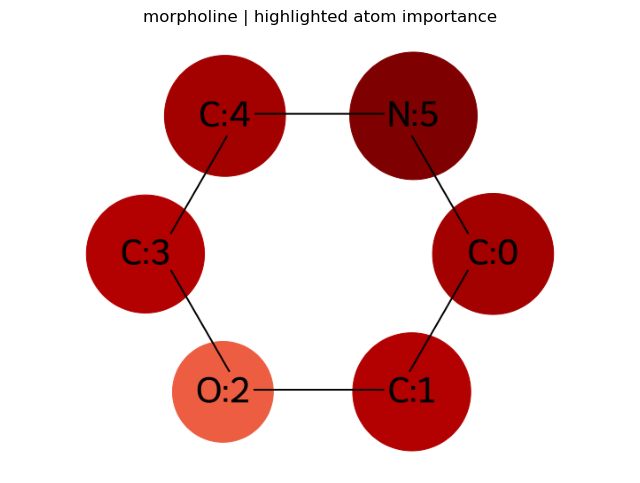

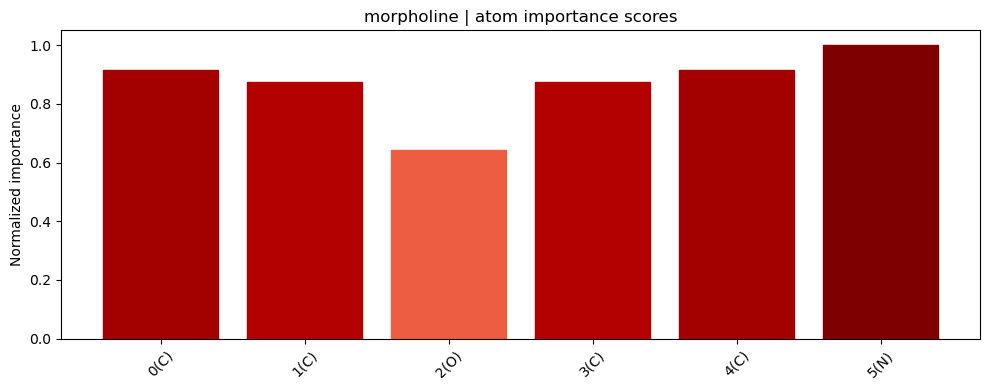

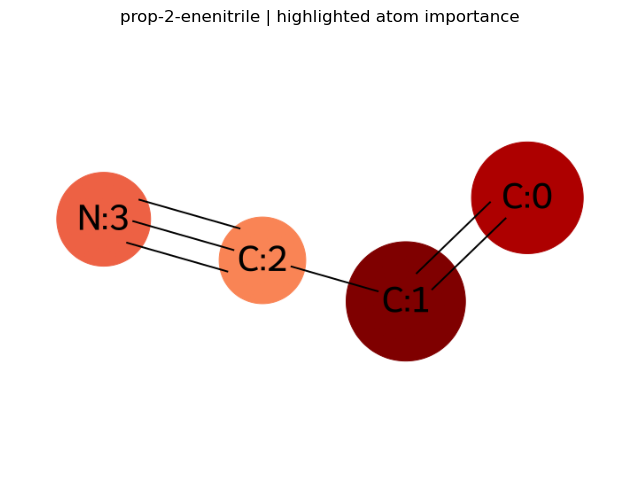

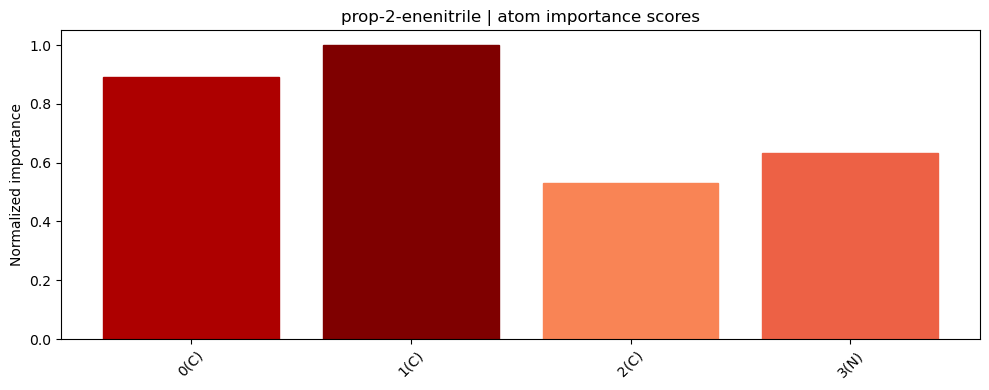

In [25]:
def find_matching_metadata_row(df_meta, graph_a, graph_b, true_target, tol=1e-6):
    """
    Find the metadata row whose SMILES atom counts match the graph node counts,
    and whose target is close to the true target.
    """
    n_a = graph_a.x.shape[0]
    n_b = graph_b.x.shape[0]

    candidate_rows = []

    for idx, row in df_meta.iterrows():
        smiles_a = row["SMILES_A"]
        smiles_b = row["SMILES_B"]

        mol_a = Chem.MolFromSmiles(smiles_a)
        mol_b = Chem.MolFromSmiles(smiles_b)

        if mol_a is None or mol_b is None:
            continue

        row_n_a = mol_a.GetNumAtoms()
        row_n_b = mol_b.GetNumAtoms()

        row_target = row["Target_neglog_molkg"] if "Target_neglog_molkg" in df_meta.columns else None

        if row_target is not None:
            target_match = abs(float(row_target) - float(true_target)) <= tol
        else:
            target_match = True

        if row_n_a == n_a and row_n_b == n_b and target_match:
            candidate_rows.append(idx)

    if len(candidate_rows) == 1:
        return candidate_rows[0]

    if len(candidate_rows) > 1:
        print("Multiple matching metadata rows found. Using first match.")
        return candidate_rows[0]

    print("No exact metadata match found. Falling back to target_idx row.")
    return None


def to_atom_importance(mol, importance):
    """
    Convert explanation output into one score per atom.
    """
    num_atoms = mol.GetNumAtoms()
    imp = np.asarray(importance, dtype=float)

    if imp.ndim == 2:
        if imp.shape[0] == num_atoms:
            return np.abs(imp).sum(axis=1)
        elif imp.shape[1] == num_atoms:
            return np.abs(imp).sum(axis=0)

    imp = imp.flatten()

    if len(imp) == num_atoms:
        return np.abs(imp)

    if len(imp) % num_atoms == 0:
        feat_dim = len(imp) // num_atoms
        return np.abs(imp.reshape(num_atoms, feat_dim)).sum(axis=1)

    raise ValueError(
        f"Cannot convert importance of length {len(imp)} to atom-level scores for molecule with {num_atoms} atoms."
    )


def normalize_atom_importance(atom_imp):
    atom_imp = np.asarray(atom_imp, dtype=float)
    if atom_imp.max() > 0:
        atom_imp = atom_imp / atom_imp.max()
    return atom_imp


def draw_molecule_with_importance(smiles, atom_importance, title="Molecule", width=700, height=500):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return

    atom_importance = normalize_atom_importance(atom_importance)

    cmap = cm.get_cmap("OrRd")
    atom_colors = {}
    atom_radii = {}

    for i, score in enumerate(atom_importance):
        rgba = cmap(float(score))
        atom_colors[i] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
        atom_radii[i] = 0.25 + 0.35 * float(score)

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = drawer.drawOptions()

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        opts.atomLabels[idx] = f"{atom.GetSymbol()}:{idx}"

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=list(atom_colors.keys()),
        highlightAtomColors=atom_colors,
        highlightAtomRadii=atom_radii
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()
    with open("temp_highlighted_mol.png", "wb") as f:
        f.write(png)

    img = plt.imread("temp_highlighted_mol.png")
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


def plot_atom_importance_bars(smiles, atom_importance, title="Atom importance"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return

    atom_importance = normalize_atom_importance(atom_importance)
    atom_labels = [f"{i}({mol.GetAtomWithIdx(i).GetSymbol()})" for i in range(len(atom_importance))]

    cmap = cm.get_cmap("OrRd")

    plt.figure(figsize=(10, 4))
    bars = plt.bar(range(len(atom_importance)), atom_importance)

    for i, b in enumerate(bars):
        b.set_color(cmap(float(atom_importance[i])))

    plt.xticks(range(len(atom_importance)), atom_labels, rotation=45)
    plt.ylabel("Normalized importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Prepare graph pair first

graph_a = prepare_single_graph(graphs_a_raw[target_idx], device)
graph_b = prepare_single_graph(graphs_b_raw[target_idx], device)

true_target = float(targets_raw[target_idx].item())
pred_target = predict_original(model, graph_a, graph_b, mixture_scaler)
toxicity_level = classify_toxicity_level(pred_target)

# Recompute explanation for this exact pair
imp_a_raw, imp_b_raw = best_explainer_fn(model, graph_a, graph_b, device)


# Find the correct metadata row

matched_idx = find_matching_metadata_row(df_meta, graph_a, graph_b, true_target)

if matched_idx is None:
    matched_idx = target_idx

smiles_a = df_meta.loc[matched_idx, "SMILES_A"]
smiles_b = df_meta.loc[matched_idx, "SMILES_B"]

drug_a_label = df_meta.loc[matched_idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else smiles_a
drug_b_label = df_meta.loc[matched_idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else smiles_b

mol_a = Chem.MolFromSmiles(smiles_a)
mol_b = Chem.MolFromSmiles(smiles_b)

print("Selected XAI method:", best_xai_method)
print("Matched metadata row:", matched_idx)
print("Drug A:", drug_a_label)
print("Drug B:", drug_b_label)
print("True mixture pLD50:", round(true_target, 4))
print("Predicted mixture pLD50:", round(pred_target, 4))
print("Predicted toxicity level:", toxicity_level)

print("\nGraph node count A:", graph_a.x.shape[0], "| SMILES atom count A:", mol_a.GetNumAtoms())
print("Graph node count B:", graph_b.x.shape[0], "| SMILES atom count B:", mol_b.GetNumAtoms())


# Convert explanation to atom-level importance

atom_imp_a = to_atom_importance(mol_a, imp_a_raw)
atom_imp_b = to_atom_importance(mol_b, imp_b_raw)


# Draw highlighted molecules

draw_molecule_with_importance(
    smiles_a,
    atom_imp_a,
    title=f"{drug_a_label} | highlighted atom importance"
)

plot_atom_importance_bars(
    smiles_a,
    atom_imp_a,
    title=f"{drug_a_label} | atom importance scores"
)

draw_molecule_with_importance(
    smiles_b,
    atom_imp_b,
    title=f"{drug_b_label} | highlighted atom importance"
)

plot_atom_importance_bars(
    smiles_b,
    atom_imp_b,
    title=f"{drug_b_label} | atom importance scores"
)

### Highlighted molecule diagrams
Atoms were highlighted using color intensity proportional to normalized importance.

- darker or stronger color = higher importance
- atom labels included symbol and atom index

This provided a direct visual map of which regions of the molecule the model relied on.

### Atom importance bar charts
Each atom’s normalized importance was shown as a bar chart, making it easier to compare importance magnitudes numerically.

These plots were useful for reporting and manual interpretation.


## Produce textual chemical explanation

In [26]:
def classify_atom_role(atom):
    symbol = atom.GetSymbol()
    is_aromatic = atom.GetIsAromatic()
    is_in_ring = atom.IsInRing()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()

    if symbol == "C" and is_aromatic:
        return "an aromatic carbon, which may belong to a hydrophobic ring system"
    elif symbol == "C" and is_in_ring:
        return "a ring carbon, which may contribute to structural rigidity"
    elif symbol == "N" and is_in_ring:
        return "a ring nitrogen, which may influence polarity, basicity, or binding behavior"
    elif symbol == "N":
        return "a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region"
    elif symbol == "O" and is_in_ring:
        return "a ring oxygen, which may contribute to polarity and oxygen-containing cyclic structure"
    elif symbol == "O":
        return "an oxygen atom, which may indicate a polar functional group such as an ether, alcohol, or carbonyl-related environment"
    elif symbol in ["Cl", "Br", "F", "I"]:
        return f"a halogen atom ({symbol}), which may increase lipophilicity and modify biological activity"
    elif symbol == "S":
        return "a sulfur atom, which may contribute to reactivity and electronic effects"
    elif formal_charge != 0:
        return f"a charged {symbol} atom, which may strongly affect intermolecular interactions"
    elif degree >= 3:
        return f"a highly connected {symbol} atom, which may lie in a structurally important region"
    else:
        return f"a {symbol} atom that may contribute to the local chemical environment"

def classify_fragment_type(mol, atom_ids):
    atoms = [mol.GetAtomWithIdx(i) for i in atom_ids]
    symbols = [a.GetSymbol() for a in atoms]

    has_aromatic = any(a.GetIsAromatic() for a in atoms)
    has_ring = any(a.IsInRing() for a in atoms)
    has_n = "N" in symbols
    has_o = "O" in symbols
    has_s = "S" in symbols
    has_halogen = any(s in ["Cl", "Br", "F", "I"] for s in symbols)

    # --- Rule-based classification ---
    if has_aromatic and has_halogen:
        return "a halogenated aromatic region (hydrophobic and bioactive)"
    
    if has_aromatic and has_n:
        return "a nitrogen-containing aromatic ring (heterocycle, often bioactive)"
    
    if has_aromatic:
        return "an aromatic hydrophobic ring"
    
    if has_ring and has_n:
        return "a nitrogen-containing heterocycle"
    
    if has_o and not has_ring:
        return "an oxygen-rich polar chain or functional group"
    
    if has_n and not has_ring:
        return "an amine-like or nitrogen-containing region"
    
    if has_s:
        return "a sulfur-containing reactive region"
    
    if has_halogen:
        return "a halogen-substituted region (affects lipophilicity and toxicity)"
    
    if has_ring:
        return "a non-aromatic ring structure"
    
    return "a general structural fragment"

def describe_fragment_chemically(mol, atom_ids):
    frag_type = classify_fragment_type(mol, atom_ids)
    return frag_type


def generate_interaction_text(label_a, label_b, drug_a_label, drug_b_label):
    """
    Generate dynamic interaction-level interpretation based on fragment types.
    Covers diverse chemical interaction scenarios.
    """

    if not label_a or not label_b:
        return (
            "The model suggests that both molecules contribute through localized structural regions, "
            "but no dominant interaction pattern could be clearly identified."
        )

    la = label_a.lower()
    lb = label_b.lower()

    # --- Case 1: Aromatic + Aromatic ---
    if "aromatic" in la and "aromatic" in lb:
        return (
            f"The model highlights aromatic regions in both {drug_a_label} and {drug_b_label}, "
            "suggesting potential π–π interactions or hydrophobic stacking effects that may influence toxicity."
        )

    # --- Case 2: Aromatic + Heteroatom ---
    if ("aromatic" in la and any(x in lb for x in ["nitrogen", "oxygen", "polar"])) or \
       ("aromatic" in lb and any(x in la for x in ["nitrogen", "oxygen", "polar"])):
        return (
            f"The model highlights an aromatic region in one molecule and a polar or heteroatom-rich region in the other, "
            f"suggesting that interactions between hydrophobic and polar functionalities may contribute to the observed toxicity."
        )

    # --- Case 3: Heterocycle + Polar ---
    if ("heterocycle" in la and "polar" in lb) or ("heterocycle" in lb and "polar" in la):
        return (
            f"The model identifies a heterocyclic structure in one molecule and a polar functional group in the other, "
            f"indicating that polarity-driven interactions and heteroatom reactivity may influence the combined toxic effect."
        )

    # --- Case 4: Halogen involvement ---
    if "halogen" in la or "halogen" in lb:
        return (
            f"The presence of halogenated regions suggests that lipophilicity and electronic effects "
            f"may play a role in modulating toxicity when these two compounds interact."
        )

    # --- Case 5: Sulfur / reactive ---
    if "sulfur" in la or "sulfur" in lb:
        return (
            f"The model highlights a sulfur-containing region, which may contribute to reactivity "
            f"and influence toxicity through electronic or metabolic interactions."
        )

    # --- Case 6: Ring + Chain ---
    if ("ring" in la and "chain" in lb) or ("ring" in lb and "chain" in la):
        return (
            f"The interaction between a cyclic structure and a flexible chain-like region "
            f"may affect molecular accessibility and reactivity, contributing to toxicity."
        )

    # --- Case 7: Both polar ---
    if "polar" in la and "polar" in lb:
        return (
            f"Both molecules contain polar functional groups, suggesting that intermolecular interactions "
            f"such as hydrogen bonding or solubility-related effects may influence toxicity."
        )

    # --- Case 8: Both general (fallback weak case) ---
    if "general" in la and "general" in lb:
        return (
            f"The model highlights general structural regions in both molecules, "
            f"suggesting that toxicity arises from distributed structural contributions rather than specific functional groups."
        )

    # --- Default fallback ---
    return (
        f"The model highlights {label_a} in {drug_a_label} and {label_b} in {drug_b_label}, "
        f"suggesting that their interaction may influence toxicity through combined structural and chemical effects."
    )


def generate_textual_explanation(
    mol_a, mol_b,
    atom_imp_a, atom_imp_b,
    pred_value, toxicity_level,
    drug_a_label, drug_b_label,
    true_value=None,
    pairkey=None,
    top_k=3
):
    atom_imp_a = np.asarray(atom_imp_a, dtype=float).flatten()
    atom_imp_b = np.asarray(atom_imp_b, dtype=float).flatten()

    # --- Top atoms ---
    top_idx_a, desc_a = get_top_atoms(mol_a, atom_imp_a, top_k=top_k)
    top_idx_b, desc_b = get_top_atoms(mol_b, atom_imp_b, top_k=top_k)

    # --- Fragments ---
    frags_a = extract_important_fragments(mol_a, atom_imp_a)
    frags_b = extract_important_fragments(mol_b, atom_imp_b)

    frag_labels_a = [classify_fragment_type(mol_a, atoms) for atoms, _ in frags_a]
    frag_labels_b = [classify_fragment_type(mol_b, atoms) for atoms, _ in frags_b]

    # --- Atom reasoning ---
    atom_reason_a = [
        f"Atom {int(i)} is {classify_atom_role(mol_a.GetAtomWithIdx(int(i)))}."
        for i in top_idx_a
    ]

    atom_reason_b = [
        f"Atom {int(i)} is {classify_atom_role(mol_b.GetAtomWithIdx(int(i)))}."
        for i in top_idx_b
    ]

    # --- Fragment descriptions ---
    frag_desc_a = [
        f"{frag_smiles} → {label}"
        for (atoms, frag_smiles), label in zip(frags_a, frag_labels_a)
    ]

    frag_desc_b = [
        f"{frag_smiles} → {label}"
        for (atoms, frag_smiles), label in zip(frags_b, frag_labels_b)
    ]

    # --- Dynamic interaction interpretation ---
    if frag_labels_a and frag_labels_b:
        combined_interpretation = generate_interaction_text(
            frag_labels_a[0],
            frag_labels_b[0],
            drug_a_label,
            drug_b_label
        )
    else:
        combined_interpretation = (
            "The model suggests that both molecules contribute through localized structural regions, "
            "but no dominant interaction pattern could be clearly identified."
        )

    # --- Prediction comparison ---
    comparison_text = ""
    if true_value is not None:
        diff = abs(pred_value - true_value)
        if diff < 0.15:
            comparison_text = "The prediction closely matches the observed toxicity."
        elif diff < 0.35:
            comparison_text = "The prediction is reasonably close to the observed value."
        else:
            comparison_text = "The prediction differs from the observed value and should be interpreted cautiously."

    pairkey_line = f"PairKey: {pairkey}\n" if pairkey else ""
    true_line = f"Observed pLD50: {true_value:.4f}\n" if true_value is not None else ""

    explanation = f"""
--- Chemical Interpretation ---

{pairkey_line}Drug A: {drug_a_label}
Drug B: {drug_b_label}

{true_line}Predicted pLD50: {pred_value:.4f}
Toxicity level: {toxicity_level}

1. Model focus

Drug A important atoms:
- {"; ".join(desc_a)}

Drug B important atoms:
- {"; ".join(desc_b)}

2. Chemical meaning of important atoms

Drug A:
- {" ".join(atom_reason_a)}

Drug B:
- {" ".join(atom_reason_b)}

3. Key structural fragments

Drug A:
- {"; ".join(frag_desc_a) if frag_desc_a else "No strong fragment"}

Drug B:
- {"; ".join(frag_desc_b) if frag_desc_b else "No strong fragment"}

4. Interaction-level interpretation

{combined_interpretation}

5. Prediction reliability

{comparison_text if comparison_text else "Observed comparison not available."}

NOTE: This explanation reflects how the model makes decisions. It does not represent a confirmed biological mechanism.
"""

    print(explanation)
    return explanation

## Save the target-pair explanation

Why this step matters
Stores the final explanation text for later reporting.

In [27]:
explanation_text = generate_textual_explanation(
    mol_a=mol_a,
    mol_b=mol_b,
    atom_imp_a=atom_imp_a,
    atom_imp_b=atom_imp_b,
    pred_value=pred_target,
    toxicity_level=toxicity_level,
    drug_a_label=drug_a_label,
    drug_b_label=drug_b_label,
    true_value=true_target,
    pairkey=df_meta.loc[matched_idx, "PairKey"] if "PairKey" in df_meta.columns else None,
    top_k=3
)

explanation_txt_path = os.path.join(processed_dir, "phase5_target_pair_explanation.txt")
with open(explanation_txt_path, "w", encoding="utf-8") as f:
    f.write(explanation_text)

print("Saved target-pair explanation to:", explanation_txt_path)


--- Chemical Interpretation ---

PairKey: C1COCCN1||C=CC#N
Drug A: morpholine
Drug B: prop-2-enenitrile

Observed pLD50: 2.1302
Predicted pLD50: 2.7745
Toxicity level: highly toxic

1. Model focus

Drug A important atoms:
- ring N sp3 degree 2 1 H (atom 5); ring C sp3 degree 2 2 H (atom 4); ring C sp3 degree 2 2 H (atom 0)

Drug B important atoms:
- C sp2 degree 2 1 H (atom 1); C sp2 degree 1 2 H (atom 0); N sp degree 1 (atom 3)

2. Chemical meaning of important atoms

Drug A:
- Atom 5 is a ring nitrogen, which may influence polarity, basicity, or binding behavior. Atom 4 is a ring carbon, which may contribute to structural rigidity. Atom 0 is a ring carbon, which may contribute to structural rigidity.

Drug B:
- Atom 1 is a C atom that may contribute to the local chemical environment. Atom 0 is a C atom that may contribute to the local chemical environment. Atom 3 is a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region.

3. Key structural fragments

Dr

The result is explaining why the model thinks this drug pair is moderately toxic by pointing to specific parts of each molecule that seem most important.

For Drug A (morpholine), the model focused mainly on the nitrogen atom inside the ring and a few carbon atoms that form the ring structure. This means the model considers the ring shape and the nitrogen inside it to be important. The nitrogen atom is special because it can affect how the molecule behaves in the body, especially how it interacts with other substances. The ring structure makes the molecule more stable and gives it a fixed shape, which can influence how it fits or reacts with other molecules.

For Drug B (prop-2-enenitrile), the model focused on carbon atoms along a short chain. Even though these atoms look simple, they form a part of the molecule that can be reactive. This means this part of the molecule may easily take part in chemical interactions, which can contribute to harmful effects.

When both drugs are considered together, the model suggests that toxicity is not caused by the whole molecules equally, but by specific parts of them. One drug has a structured ring with a nitrogen that can interact strongly, while the other has a simpler but more reactive chain. The combination of a stable structure from one drug and a reactive part from the other may increase the overall harmful effect when they are present together.

In simple terms, the model is saying that certain small regions in each drug are more important than the rest, and when those regions interact, they may lead to higher toxicity.

## Reusable function to explain any pair by index or name

In [28]:
def explain_pair(
    model,
    df_meta,
    graphs_a,
    graphs_b,
    scaler,
    device,
    explainer_fn,
    idx=None,
    pairkey=None,
    smiles_a=None,
    smiles_b=None,
    top_k=3,
    save_outputs=True,
    save_dir=None,
    show_plots=True
):
    """
    Explain any pair by:
    - direct row index
    - PairKey
    - SMILES_A + SMILES_B

    Outputs:
    - prediction
    - atom-level importance
    - richer textual interpretation
    - highlighted molecule plots
    - bar plots
    - saved text/json/image outputs

    Returns a dictionary with all major outputs.
    """

    idx = find_pair_index(
        df_meta,
        pairkey=pairkey,
        smiles_a=smiles_a,
        smiles_b=smiles_b,
        idx=idx
    )

    g_a = prepare_single_graph(graphs_a[idx], device)
    g_b = prepare_single_graph(graphs_b[idx], device)

    pred = predict_original(model, g_a, g_b, scaler)
    true_val = float(targets_raw[idx].item())
    toxicity_level = classify_toxicity_level(pred)

    imp_a_raw, imp_b_raw = explainer_fn(model, g_a, g_b, device)

    smiles_a_row = df_meta.loc[idx, "SMILES_A"]
    smiles_b_row = df_meta.loc[idx, "SMILES_B"]

    mol_a = Chem.MolFromSmiles(smiles_a_row)
    mol_b = Chem.MolFromSmiles(smiles_b_row)

    if mol_a is None or mol_b is None:
        raise ValueError("Invalid SMILES found in metadata.")

    atom_imp_a = to_atom_importance(mol_a, imp_a_raw)
    atom_imp_b = to_atom_importance(mol_b, imp_b_raw)

    atom_imp_a = normalize_atom_importance(atom_imp_a)
    atom_imp_b = normalize_atom_importance(atom_imp_b)

    drug_a_label = df_meta.loc[idx, "CommonName_A"] if "CommonName_A" in df_meta.columns else smiles_a_row
    drug_b_label = df_meta.loc[idx, "CommonName_B"] if "CommonName_B" in df_meta.columns else smiles_b_row

    pairkey_value = df_meta.loc[idx, "PairKey"] if "PairKey" in df_meta.columns else f"pair_{idx}"
    source_value = df_meta.loc[idx, "source"] if "source" in df_meta.columns else None


    # Richer chemical interpretation pieces
    top_idx_a, desc_a = get_top_atoms(mol_a, atom_imp_a, top_k=top_k)
    top_idx_b, desc_b = get_top_atoms(mol_b, atom_imp_b, top_k=top_k)

    atom_reason_a = []
    for i in top_idx_a:
        atom = mol_a.GetAtomWithIdx(int(i))
        atom_reason_a.append(f"Atom {int(i)} is {classify_atom_role(atom)}.")

    atom_reason_b = []
    for i in top_idx_b:
        atom = mol_b.GetAtomWithIdx(int(i))
        atom_reason_b.append(f"Atom {int(i)} is {classify_atom_role(atom)}.")

    frags_a = extract_important_fragments(mol_a, atom_imp_a)
    frags_b = extract_important_fragments(mol_b, atom_imp_b)

    frag_labels_a = [classify_fragment_type(mol_a, atoms) for atoms, _ in frags_a]
    frag_labels_b = [classify_fragment_type(mol_b, atoms) for atoms, _ in frags_b]

    frag_desc_a = [f"{frag_smiles} → {label}" for (atoms, frag_smiles), label in zip(frags_a, frag_labels_a)]
    frag_desc_b = [f"{frag_smiles} → {label}" for (atoms, frag_smiles), label in zip(frags_b, frag_labels_b)]


    combined_interpretation = ""
    # dynamic interaction logic
    if frag_labels_a and frag_labels_b:
        combined_interpretation = generate_interaction_text(
            frag_labels_a[0],
            frag_labels_b[0],
            drug_a_label,
            drug_b_label
        )
    else:
        combined_interpretation = (
            "The model suggests that both molecules contribute through localized structural regions, "
            "but no dominant interaction pattern could be clearly identified."
        )


    comparison_text = ""
    diff = abs(pred - true_val)
    if diff < 0.15:
        comparison_text = "The prediction closely matches the observed toxicity."
    elif diff < 0.35:
        comparison_text = "The prediction is reasonably close to the observed value."
    else:
        comparison_text = "The prediction differs from the observed value and should be interpreted cautiously."

    explanation_text = generate_textual_explanation(
        mol_a=mol_a,
        mol_b=mol_b,
        atom_imp_a=atom_imp_a,
        atom_imp_b=atom_imp_b,
        pred_value=pred,
        toxicity_level=toxicity_level,
        drug_a_label=drug_a_label,
        drug_b_label=drug_b_label,
        true_value=true_val,
        pairkey=pairkey_value,
        top_k=top_k
    )

    saved_paths = {}


    # Save directory
    if save_outputs:
        if save_dir is None:
            save_dir = os.path.join(processed_dir, "phase5_explanations")
        os.makedirs(save_dir, exist_ok=True)

        safe_pair_name = str(pairkey_value).replace("||", "__").replace("/", "_").replace("\\", "_").replace(":", "_")

        try:
            text_path = os.path.join(save_dir, f"{safe_pair_name}_explanation.txt")
            with open(text_path, "w", encoding="utf-8") as f:
                f.write(explanation_text)
            saved_paths["text_explanation"] = text_path
        except Exception as e:
            print(f"Warning: could not save text explanation for idx {idx}: {e}")
            saved_paths["text_explanation"] = None


    # Plot save helpers
    def save_highlighted_molecule(smiles, atom_importance, title, out_path=None, show=True):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        atom_importance_local = normalize_atom_importance(atom_importance)

        import matplotlib.cm as cm
        from rdkit.Chem.Draw import rdMolDraw2D

        cmap = cm.get_cmap("OrRd")
        atom_colors = {}
        atom_radii = {}

        for i, score in enumerate(atom_importance_local):
            rgba = cmap(float(score))
            atom_colors[i] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
            atom_radii[i] = 0.25 + 0.35 * float(score)

        drawer = rdMolDraw2D.MolDraw2DCairo(700, 500)
        opts = drawer.drawOptions()

        for atom in mol.GetAtoms():
            atom_idx = atom.GetIdx()
            opts.atomLabels[atom_idx] = f"{atom.GetSymbol()}:{atom_idx}"

        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer,
            mol,
            highlightAtoms=list(atom_colors.keys()),
            highlightAtomColors=atom_colors,
            highlightAtomRadii=atom_radii
        )
        drawer.FinishDrawing()

        png = drawer.GetDrawingText()

        if out_path is not None:
            with open(out_path, "wb") as f:
                f.write(png)

        if show:
            temp_path = out_path if out_path is not None else "temp_highlighted_mol.png"
            if out_path is None:
                with open(temp_path, "wb") as f:
                    f.write(png)

            img = plt.imread(temp_path)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(title)
            plt.show()

        return out_path

    def save_importance_barplot(smiles, atom_importance, title, out_path=None, show=True):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        atom_importance_local = normalize_atom_importance(atom_importance)

        import matplotlib.cm as cm
        cmap = cm.get_cmap("OrRd")
        atom_labels = [f"{i}({mol.GetAtomWithIdx(i).GetSymbol()})" for i in range(len(atom_importance_local))]

        plt.figure(figsize=(10, 4))
        bars = plt.bar(range(len(atom_importance_local)), atom_importance_local)

        for i, b in enumerate(bars):
            b.set_color(cmap(float(atom_importance_local[i])))

        plt.xticks(range(len(atom_importance_local)), atom_labels, rotation=45)
        plt.ylabel("Normalized importance")
        plt.title(title)
        plt.tight_layout()

        if out_path is not None:
            plt.savefig(out_path, dpi=300, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()

        return out_path

    if save_outputs:
        img_a_path = os.path.join(save_dir, f"{safe_pair_name}_drugA_highlight.png")
        img_b_path = os.path.join(save_dir, f"{safe_pair_name}_drugB_highlight.png")
        bar_a_path = os.path.join(save_dir, f"{safe_pair_name}_drugA_bars.png")
        bar_b_path = os.path.join(save_dir, f"{safe_pair_name}_drugB_bars.png")
    else:
        img_a_path = img_b_path = bar_a_path = bar_b_path = None

    # Save / show figures
    try:
        save_highlighted_molecule(
            smiles=smiles_a_row,
            atom_importance=atom_imp_a,
            title=f"{drug_a_label} | highlighted atom importance",
            out_path=img_a_path,
            show=show_plots
        )
        saved_paths["drugA_highlight"] = img_a_path
    except Exception as e:
        print(f"Warning: could not save Drug A highlight for idx {idx}: {e}")
        saved_paths["drugA_highlight"] = None

    try:
        save_importance_barplot(
            smiles=smiles_a_row,
            atom_importance=atom_imp_a,
            title=f"{drug_a_label} | atom importance scores",
            out_path=bar_a_path,
            show=show_plots
        )
        saved_paths["drugA_bars"] = bar_a_path
    except Exception as e:
        print(f"Warning: could not save Drug A bars for idx {idx}: {e}")
        saved_paths["drugA_bars"] = None

    try:
        save_highlighted_molecule(
            smiles=smiles_b_row,
            atom_importance=atom_imp_b,
            title=f"{drug_b_label} | highlighted atom importance",
            out_path=img_b_path,
            show=show_plots
        )
        saved_paths["drugB_highlight"] = img_b_path
    except Exception as e:
        print(f"Warning: could not save Drug B highlight for idx {idx}: {e}")
        saved_paths["drugB_highlight"] = None

    try:
        save_importance_barplot(
            smiles=smiles_b_row,
            atom_importance=atom_imp_b,
            title=f"{drug_b_label} | atom importance scores",
            out_path=bar_b_path,
            show=show_plots
        )
        saved_paths["drugB_bars"] = bar_b_path
    except Exception as e:
        print(f"Warning: could not save Drug B bars for idx {idx}: {e}")
        saved_paths["drugB_bars"] = None

    # Save rich summary JSON
    if save_outputs:
        try:
            summary_path = os.path.join(save_dir, f"{safe_pair_name}_summary.json")
            summary_data = {
                "idx": int(idx),
                "pairkey": pairkey_value,
                "source": source_value,
                "drug_a_label": drug_a_label,
                "drug_b_label": drug_b_label,
                "smiles_a": smiles_a_row,
                "smiles_b": smiles_b_row,
                "true_pLD50": float(true_val),
                "pred_pLD50": float(pred),
                "absolute_error": float(abs(pred - true_val)),
                "toxicity_level": toxicity_level,
                "top_atoms_a": desc_a,
                "top_atoms_b": desc_b,
                "atom_reason_a": atom_reason_a,
                "atom_reason_b": atom_reason_b,
                "fragment_labels_a": frag_labels_a,
                "fragment_labels_b": frag_labels_b,
                "fragment_descriptions_a": frag_desc_a,
                "fragment_descriptions_b": frag_desc_b,
                "interaction_interpretation": combined_interpretation,
                "prediction_reliability": comparison_text,
                "xai_method": best_xai_method
            }
            with open(summary_path, "w", encoding="utf-8") as f:
                json.dump(summary_data, f, indent=2)
            saved_paths["summary_json"] = summary_path
        except Exception as e:
            print(f"Warning: could not save summary json for idx {idx}: {e}")
            saved_paths["summary_json"] = None

    # Console output
    print(f"\n=== Explanation for pair index {idx} ===")
    print("Drug A:", drug_a_label)
    print("Drug B:", drug_b_label)
    print("PairKey:", pairkey_value)
    print("True mixture pLD50:", round(true_val, 4))
    print("Predicted mixture pLD50:", round(pred, 4))
    print("Predicted toxicity level:", toxicity_level)
    print("Top atoms in Drug A:", desc_a)
    print("Top atoms in Drug B:", desc_b)
    print("Atom meaning in Drug A:", atom_reason_a)
    print("Atom meaning in Drug B:", atom_reason_b)
    print("Fragments in Drug A:", frag_desc_a if frag_desc_a else ["No strong fragment"])
    print("Fragments in Drug B:", frag_desc_b if frag_desc_b else ["No strong fragment"])
    print("Interaction-level interpretation:", combined_interpretation)
    print("Prediction reliability:", comparison_text)

    return {
        "idx": idx,
        "pairkey": pairkey_value,
        "source": source_value,
        "drug_a_label": drug_a_label,
        "drug_b_label": drug_b_label,
        "smiles_a": smiles_a_row,
        "smiles_b": smiles_b_row,
        "true_pLD50": true_val,
        "pred_pLD50": pred,
        "toxicity_level": toxicity_level,
        "top_atoms_a": desc_a,
        "top_atoms_b": desc_b,
        "atom_reason_a": atom_reason_a,
        "atom_reason_b": atom_reason_b,
        "fragment_labels_a": frag_labels_a,
        "fragment_labels_b": frag_labels_b,
        "fragment_descriptions_a": frag_desc_a,
        "fragment_descriptions_b": frag_desc_b,
        "interaction_interpretation": combined_interpretation,
        "prediction_reliability": comparison_text,
        "explanation_text": explanation_text,
        "saved_paths": saved_paths
    }

## Save selected explanations for the benchmark subset

This gives you a compact CSV of example explanations across several unseen pairs.

In [29]:
rows = []

benchmark_save_dir = os.path.join(processed_dir, "phase5_benchmark_outputs")
os.makedirs(benchmark_save_dir, exist_ok=True)

for idx in benchmark_indices:
    try:
        result = explain_pair(
            model=model,
            df_meta=df_meta,
            graphs_a=graphs_a_raw,
            graphs_b=graphs_b_raw,
            scaler=mixture_scaler,
            device=device,
            explainer_fn=best_explainer_fn,
            idx=int(idx),
            top_k=3,
            save_outputs=True,
            save_dir=benchmark_save_dir,
            show_plots=False
        )

        rows.append({
            "idx": int(result["idx"]),
            "PairKey": result["pairkey"],
            "DrugA": result["drug_a_label"],
            "DrugB": result["drug_b_label"],
            "source": result["source"],
            "SMILES_A": result["smiles_a"],
            "SMILES_B": result["smiles_b"],
            "true_pLD50": result["true_pLD50"],
            "pred_pLD50": result["pred_pLD50"],
            "toxicity_level": result["toxicity_level"],
            "top_atoms_A": "; ".join(result["top_atoms_a"]),
            "top_atoms_B": "; ".join(result["top_atoms_b"]),
            "atom_reason_A": " ".join(result["atom_reason_a"]) if "atom_reason_a" in result else None,
            "atom_reason_B": " ".join(result["atom_reason_b"]) if "atom_reason_b" in result else None,
            "fragment_labels_A": "; ".join(result["fragment_labels_a"]) if "fragment_labels_a" in result else None,
            "fragment_labels_B": "; ".join(result["fragment_labels_b"]) if "fragment_labels_b" in result else None,
            "fragment_desc_A": "; ".join(result["fragment_descriptions_a"]) if "fragment_descriptions_a" in result else None,
            "fragment_desc_B": "; ".join(result["fragment_descriptions_b"]) if "fragment_descriptions_b" in result else None,
            "interaction_interpretation": result["interaction_interpretation"] if "interaction_interpretation" in result else None,
            "prediction_reliability": result["prediction_reliability"] if "prediction_reliability" in result else None,
            "interpretation_text": result["explanation_text"],
            "xai_method": best_xai_method,
            "text_path": result["saved_paths"].get("text_explanation"),
            "drugA_highlight_path": result["saved_paths"].get("drugA_highlight"),
            "drugB_highlight_path": result["saved_paths"].get("drugB_highlight"),
            "drugA_bars_path": result["saved_paths"].get("drugA_bars"),
            "drugB_bars_path": result["saved_paths"].get("drugB_bars"),
            "summary_json_path": result["saved_paths"].get("summary_json")
        })

    except Exception as e:
        print(f"Skipping idx {idx} due to error: {e}")

df_explanations = pd.DataFrame(rows)

selected_explanations_path = os.path.join(processed_dir, "phase5_selected_explanations.csv")
df_explanations.to_csv(selected_explanations_path, index=False)

print("\nSaved benchmark explanations to:", selected_explanations_path)
print("Number of saved rows:", len(df_explanations))


--- Chemical Interpretation ---

PairKey: C1COCCN1||OCCOc1ccccc1
Drug A: morpholine
Drug B: 2-phenoxyethanol

Observed pLD50: 1.4406
Predicted pLD50: 1.7298
Toxicity level: mildly toxic

1. Model focus

Drug A important atoms:
- ring N sp3 degree 2 1 H (atom 5); ring C sp3 degree 2 2 H (atom 4); ring C sp3 degree 2 2 H (atom 0)

Drug B important atoms:
- aromatic C sp2 degree 3 (atom 4); O sp2 degree 2 (atom 3); aromatic C sp2 degree 2 1 H (atom 9)

2. Chemical meaning of important atoms

Drug A:
- Atom 5 is a ring nitrogen, which may influence polarity, basicity, or binding behavior. Atom 4 is a ring carbon, which may contribute to structural rigidity. Atom 0 is a ring carbon, which may contribute to structural rigidity.

Drug B:
- Atom 4 is an aromatic carbon, which may belong to a hydrophobic ring system. Atom 3 is an oxygen atom, which may indicate a polar functional group such as an ether, alcohol, or carbonyl-related environment. Atom 9 is an aromatic carbon, which may belong to

In [30]:
if len(df_explanations) > 0:
    display(df_explanations.head())
else:
    print("No rows were saved. Check earlier warnings/errors.")

,idx,PairKey,DrugA,DrugB,source,SMILES_A,SMILES_B,true_pLD50,pred_pLD50,toxicity_level,...,interaction_interpretation,prediction_reliability,interpretation_text,xai_method,text_path,drugA_highlight_path,drugB_highlight_path,drugA_bars_path,drugB_bars_path,summary_json_path
0,26,C1COCCN1||OCCOc1ccccc1,morpholine,2-phenoxyethanol,Smyth,C1COCCN1,OCCOc1ccccc1,1.440614,1.729769,mildly toxic,...,The model highlights an aromatic region in one...,The prediction is reasonably close to the obse...,\n--- Chemical Interpretation ---\n\nPairKey: ...,IntegratedGradients,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
1,132,CC#N||O=[N+]([O-])c1ccccc1,acetonitrile,nitrobenzene,Smyth,CC#N,O=[N+]([O-])c1ccccc1,1.872586,1.955075,mildly toxic,...,The model highlights a general structural frag...,The prediction closely matches the observed to...,\n--- Chemical Interpretation ---\n\nPairKey: ...,IntegratedGradients,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
2,337,CNC.O=C(O)COc1ccc(Cl)cc1Cl||Cc1nn(-c2cc(NS(C)(...,"2-(2,4-dichlorophenoxy)acetic acid;N-methylmet...","N-[2,4-dichloro-5-[4-(difluoromethyl)-3-methyl...",Acute_Oral_Toxicity,CNC.O=C(O)COc1ccc(Cl)cc1Cl,Cc1nn(-c2cc(NS(C)(=O)=O)c(Cl)cc2Cl)c(=O)n1C(F)F,2.719562,2.832503,highly toxic,...,The model highlights aromatic regions in both ...,The prediction closely matches the observed to...,\n--- Chemical Interpretation ---\n\nPairKey: ...,IntegratedGradients,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
3,119,CC#N||CC(O)CO,acetonitrile,"propane-1,2-diol",Smyth,CC#N,CC(O)CO,0.404346,0.984579,very mildly toxic,...,The model highlights a general structural frag...,The prediction differs from the observed value...,\n--- Chemical Interpretation ---\n\nPairKey: ...,IntegratedGradients,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...
4,329,CCO||OCCOCCOCCOCCOCCOCCOCCOCCO,ethanol,2-[2-[2-[2-[2-[2-[2-(2-hydroxyethoxy)ethoxy]et...,Smyth,CCO,OCCOCCOCCOCCOCCOCCOCCOCCO,0.734605,0.737179,very mildly toxic,...,Both molecules contain polar functional groups...,The prediction closely matches the observed to...,\n--- Chemical Interpretation ---\n\nPairKey: ...,IntegratedGradients,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...,C:\Users\msi\Downloads\IRP Jupiter nb\Data\pro...


| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


In [31]:
df_meta.head()

,PairKey,SMILES_A,SMILES_B,Target_neglog_molkg,source,DrugA,DrugB,CommonName_A,CommonName_B
0,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1||CCCCC...,C#CCOC(=O)C(C)Oc1ccc(Oc2ncc(Cl)cc2F)cc1,CCCCCC(C)OC(=O)COc1ccc(Cl)c2cccnc12,2.737919,Acute_Oral_Toxicity,Drug_A_0,Drug_B_0,prop-2-ynyl 2-[4-[(5-chloro-3-fluoro-2-pyridin...,heptan-2-yl 2-(5-chloroquinolin-8-yl)oxyacetate
1,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,2.499312,Acute_Oral_Toxicity,Drug_A_1,Drug_B_1,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,1-[[2-[2-chloro-4-(4-chlorophenoxy)phenyl]-4-m...
2,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC|...,C#CCOc1ccc(CCNC(=O)C(OCC#C)c2ccc(Cl)cc2)cc1OC,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.403102,Acute_Oral_Toxicity,Drug_A_2,Drug_B_2,2-(4-chlorophenyl)-N-[2-(3-methoxy-4-prop-2-yn...,"2,4,5,6-tetrachlorobenzene-1,3-dicarbonitrile"
3,C1COCCN1||C1COCCO1,C1COCCN1,C1COCCO1,1.359363,Smyth,Drug_A_3,Drug_B_3,morpholine,"1,4-dioxane"
4,C1COCCN1||C=CC#N,C1COCCN1,C=CC#N,2.130152,Smyth,Drug_A_4,Drug_B_4,morpholine,prop-2-enenitrile


In [32]:
meta_path = os.path.join(processed_dir, "phase5_meta_df_useing_pubchem.csv")
df_meta.to_csv(meta_path, index=False)